# STROKE PREDICTION USING MACHINE LEARNING

# Libraries

In [1]:
# Data Processing
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder 

# Normalizing the data
from sklearn.preprocessing import MinMaxScaler

# Model Building
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier as xgb
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import learning_curve
from sklearn.tree import export_graphviz
import graphviz

# 1. Data Import

In [2]:
# Importing the dataset
path = "C:/Users/Dellb/OneDrive/Desktop/stroke_data.csv/stroke_data.csv"
data = pd.read_csv(path)
data

,sex,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,63,0,1,1,4,1,228.69,36.6,1,1
1,1.0,42,0,1,1,4,0,105.92,32.5,0,1
2,0.0,61,0,0,1,4,1,171.23,34.4,1,1
3,1.0,41,1,0,1,3,0,174.12,24.0,0,1
4,1.0,85,0,0,1,4,1,186.21,29.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
40905,1.0,38,0,0,0,4,1,120.94,29.7,1,0
40906,0.0,53,0,0,1,4,0,77.66,40.8,0,0
40907,1.0,32,0,0,1,2,0,231.95,33.2,0,0
40908,1.0,42,0,0,1,3,0,216.38,34.5,0,0


# 2. Exploratory Data Analysis (EDA)

# 2.1 General EDA 

A look at the basic characterisitics of the dataset

In [3]:
# to check the dimensions of the dataset
print("1. The number of rows and columns in the dataset -",data.shape)

# columns present in the dataset
print("\n2. The columns present in the dataset are:\n ",data.columns)

# summary of the dataset
print("\n3.Data Summary\n")
print(data.info())

# number of unique values in each variables
print("\n4. Number of Unique Values in each variable.\n")
print(data.nunique())

1. The number of rows and columns in the dataset - (40910, 11)

2. The columns present in the dataset are:
  Index(['sex', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

3.Data Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40910 entries, 0 to 40909
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex                40907 non-null  float64
 1   age                40910 non-null  int64  
 2   hypertension       40910 non-null  int64  
 3   heart_disease      40910 non-null  int64  
 4   ever_married       40910 non-null  int64  
 5   work_type          40910 non-null  int64  
 6   Residence_type     40910 non-null  int64  
 7   avg_glucose_level  40910 non-null  float64
 8   bmi                40910 non-null  float64
 9   smoking_status     40910 non-null  int

# 2.2 Missing Values and Duplicate Values

In [4]:
# checking for missing values
print("1. Checking for missing values in each column:")
print(data.isnull().sum())

# checking for Duplicate values
print("\n2. Number of Duplicate Values in the dataset:",data.duplicated().sum())

1. Checking for missing values in each column:
sex                  3
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

2. Number of Duplicate Values in the dataset: 0


# 2.3 Labelling

For Visualization purposes, we will label the data. 
Change numerical variables into categorical.

In [5]:
# Change the name of the column
data.rename(columns={'sex': 'gender'}, inplace=True)

In [6]:
data = data.copy()

# Mapping dictionaries for each column
gender_mapping = {0: 'Female', 1: 'Male'}
hypertension_mapping = {0: 'No hypertension', 1: 'hypertension'}
heart_disease_mapping = {0: 'No heart disease', 1: 'heart disease'}
ever_married_mapping = {0: 'No', 1: 'Yes'}
work_type_mapping = {0: 'Never worked', 1: 'Children', 2: 'Govt job', 3: 'Self-employed', 4: 'Private'}
residence_type_mapping = {0: 'Urban', 1: 'Rural'}
smoking_status_mapping = {0: 'Never smoked', 1: 'Smokes'}
stroke_mapping = {0: 'No', 1: 'Yes'}

# Use the replace() method to map the numerical codes to the corresponding labels
data['gender'] = data['gender'].replace(gender_mapping)
data['hypertension'] = data['hypertension'].replace(hypertension_mapping)
data['heart_disease'] = data['heart_disease'].replace(heart_disease_mapping)
data['ever_married'] = data['ever_married'].replace(ever_married_mapping)
data['work_type'] = data['work_type'].replace(work_type_mapping)
data['Residence_type'] = data['Residence_type'].replace(residence_type_mapping)
data['smoking_status'] = data['smoking_status'].replace(smoking_status_mapping)

data.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,63,No hypertension,heart disease,Yes,Private,Rural,228.69,36.6,Smokes,1
1,Male,42,No hypertension,heart disease,Yes,Private,Urban,105.92,32.5,Never smoked,1
2,Female,61,No hypertension,No heart disease,Yes,Private,Rural,171.23,34.4,Smokes,1
3,Male,41,hypertension,No heart disease,Yes,Self-employed,Urban,174.12,24.0,Never smoked,1
4,Male,85,No hypertension,No heart disease,Yes,Private,Rural,186.21,29.0,Smokes,1
5,Male,55,hypertension,heart disease,Yes,Private,Urban,70.09,27.4,Never smoked,1
6,Female,82,No hypertension,No heart disease,No,Private,Rural,94.39,22.8,Never smoked,1
7,Female,17,hypertension,No heart disease,Yes,Private,Urban,80.43,29.7,Never smoked,1
8,Male,31,No hypertension,heart disease,Yes,Govt job,Urban,120.46,36.8,Smokes,1
9,Female,55,No hypertension,No heart disease,Yes,Private,Rural,104.51,27.3,Smokes,1


# 2.4 Statistical EDA

In [7]:
# descriptive statistics on numerical variables
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,40910.0,51.327255,21.623969,-9.00,35.00,52.00,68.00,103.00
avg_glucose_level,40910.0,122.075901,57.561531,55.12,78.75,97.92,167.59,271.74
bmi,40910.0,30.406355,6.835072,11.50,25.90,29.40,34.10,92.00
stroke,40910.0,0.500122,0.500006,0.00,0.00,1.00,1.00,1.00


In [8]:
# statistics on categorical variables
data.describe(include='object').T

,count,unique,top,freq
gender,40907,2,Male,22710
hypertension,40910,2,No hypertension,32162
heart_disease,40910,2,No heart disease,35685
ever_married,40910,2,Yes,33601
work_type,40910,5,Private,25570
Residence_type,40910,2,Rural,21064
smoking_status,40910,2,Never smoked,20921


# 2.5 Visualization

For visualization, we will look at the distibution of values in each variable. Also, the relationship between the each variable with the target variable. It will help us answer some of the questions.

# Gender

gender
Male      22710
Female    18197
Name: count, dtype: int64


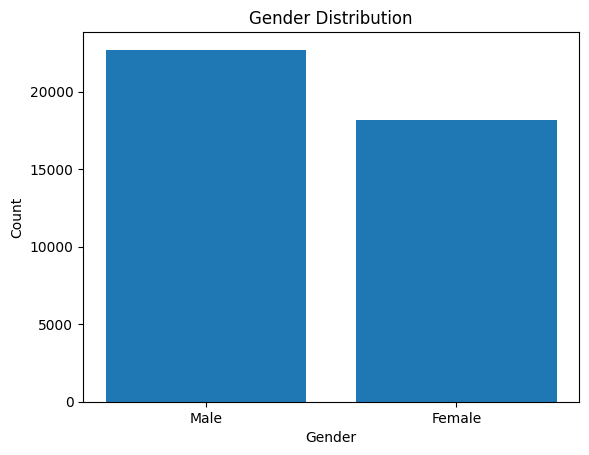

In [9]:
# counting
gender_counts = data['gender'].value_counts()
print(gender_counts)

# bar chart
plt.bar(gender_counts.index, gender_counts.values)

# plot chart
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

# Gender and Stroke

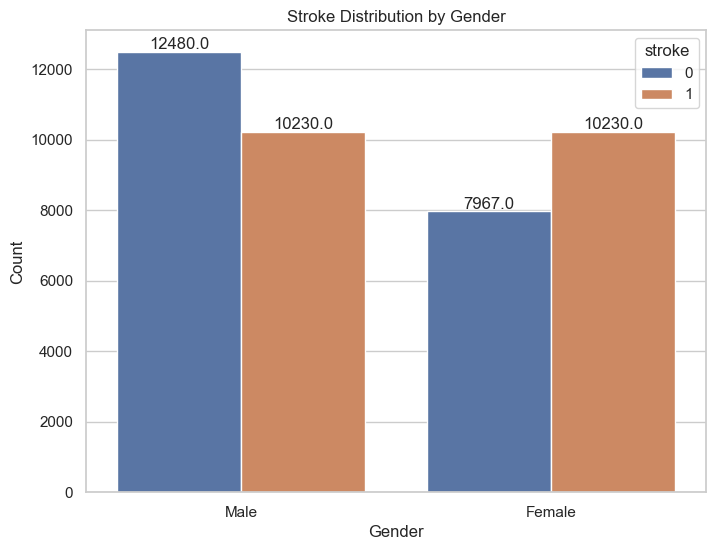

In [10]:
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='gender', hue='stroke', data=data) 

# Add counts 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

# plot chart
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Stroke Distribution by Gender')
plt.show()

In [11]:
# calculate the mean of 'stroke' for each group
gender_stroke_mean = data.groupby('gender')['stroke'].mean().sort_values()
print(gender_stroke_mean*100)

gender
Male      45.046235
Female    56.218058
Name: stroke, dtype: float64


# Ever Married

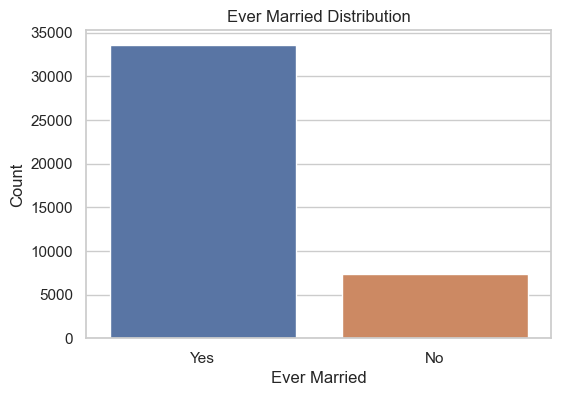

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='ever_married', data=data)

# plot chart
plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.title('Ever Married Distribution')
plt.show()

# Ever Married and Stroke

ever_married
Yes    33601
No      7309
Name: count, dtype: int64


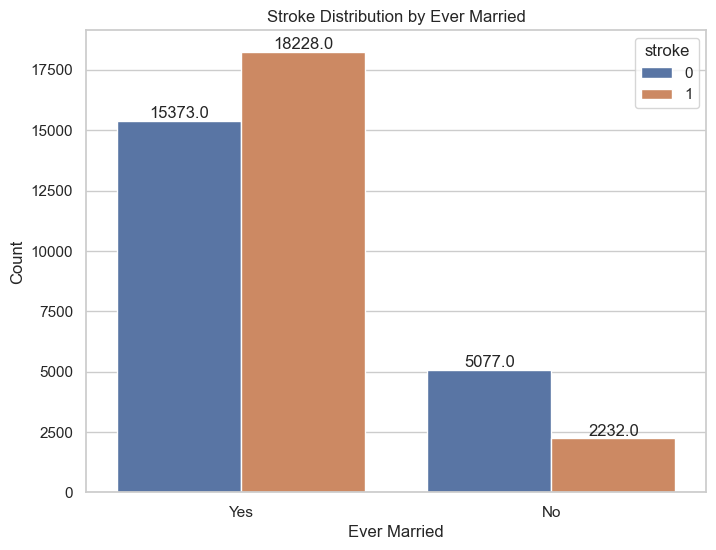

In [13]:
# counting
gender_counts = data['ever_married'].value_counts()
print(gender_counts)
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='ever_married', hue='stroke', data=data)

# Add counts 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.title('Stroke Distribution by Ever Married')
plt.show()

In [14]:
# calculate the mean of 'stroke' for each group
married_stroke_mean = data.groupby('ever_married')['stroke'].mean().sort_values()
print(married_stroke_mean)

ever_married
No     0.305377
Yes    0.542484
Name: stroke, dtype: float64


# Work Type

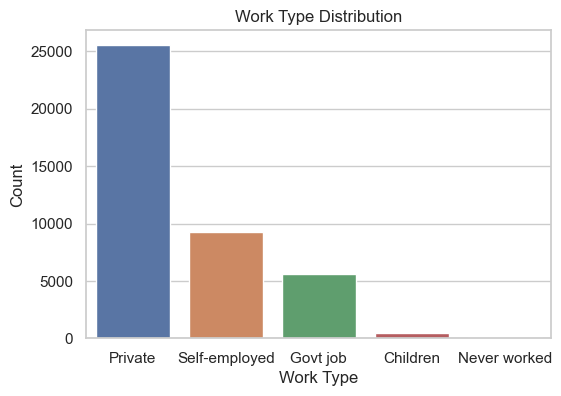

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='work_type', data=data)

plt.xlabel('Work Type')
plt.ylabel('Count')
plt.title('Work Type Distribution')
plt.show()

# Work Type and Stroke

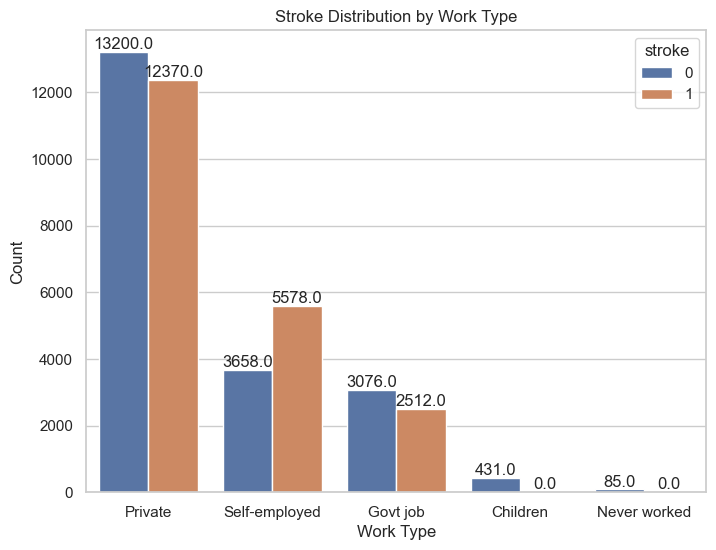

In [16]:
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='work_type', hue='stroke', data=data) 

# Add counts 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.xlabel('Work Type')
plt.ylabel('Count')
plt.title('Stroke Distribution by Work Type')
plt.show()

In [17]:
# calculate the mean of 'stroke' for each group
work_stroke_mean = data.groupby('work_type')['stroke'].mean().sort_values()
print(work_stroke_mean)

work_type
Children         0.000000
Never worked     0.000000
Govt job         0.449535
Private          0.483770
Self-employed    0.603941
Name: stroke, dtype: float64


# Residence Type

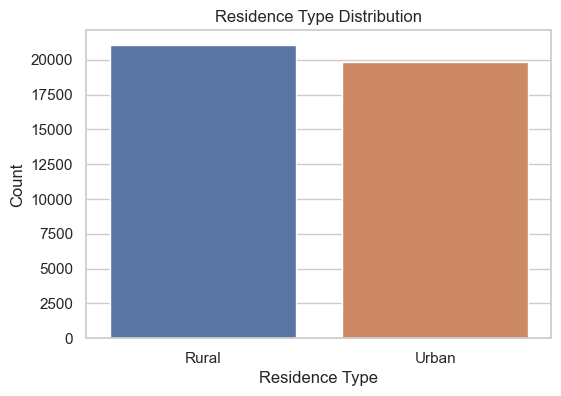

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Residence_type', data=data)

plt.xlabel('Residence Type')
plt.ylabel('Count')
plt.title('Residence Type Distribution')
plt.show()

# Residence Type and Stroke

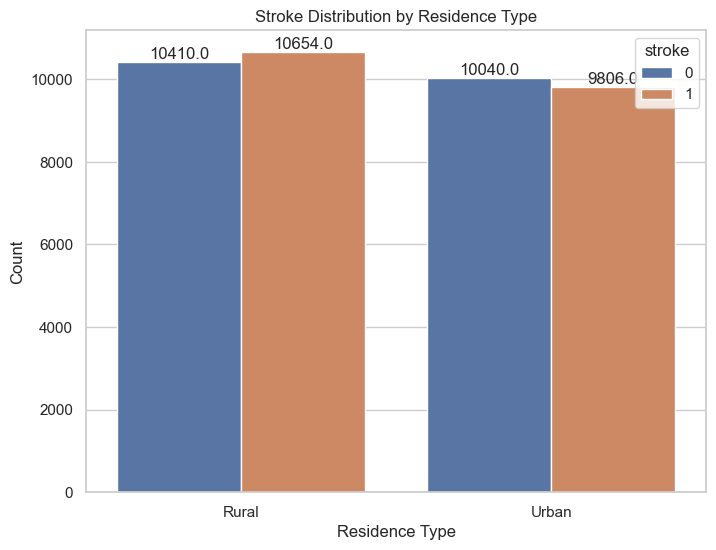

In [19]:
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='Residence_type', hue='stroke', data=data) 

# Add counts 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.xlabel('Residence Type')
plt.ylabel('Count')
plt.title('Stroke Distribution by Residence Type')
plt.show()

In [20]:
# calculate the mean of 'stroke' for each group
residence_stroke_mean = data.groupby('Residence_type')['stroke'].mean().sort_values()
print(residence_stroke_mean)

Residence_type
Urban    0.494105
Rural    0.505792
Name: stroke, dtype: float64


# Hypertension

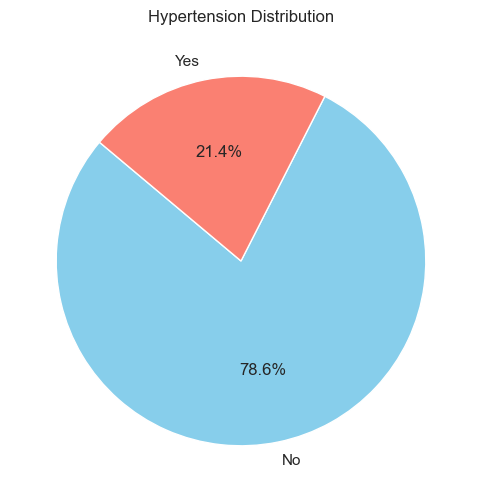

In [21]:
hypertension_counts = data['hypertension'].value_counts()

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(hypertension_counts, labels=['No', 'Yes'], colors=['skyblue', 'salmon'], autopct='%1.1f%%', startangle=140)

plt.title('Hypertension Distribution')
plt.show()

# Hypertension and Stroke

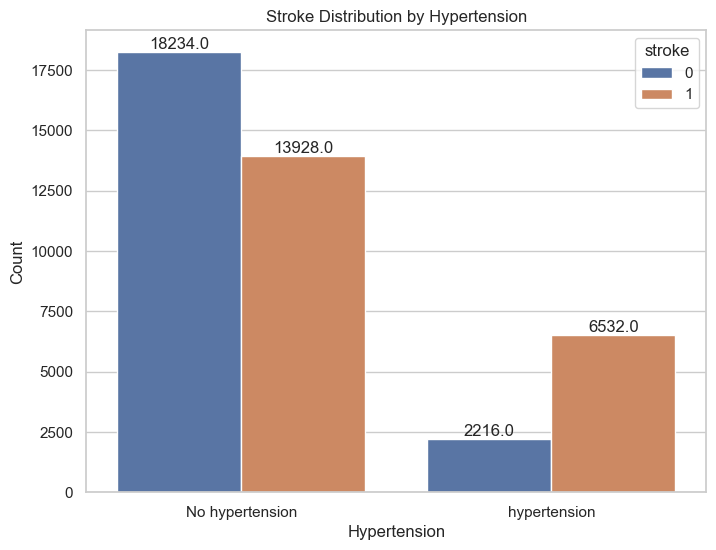

In [22]:
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='hypertension', hue='stroke', data=data) 

# Add counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

plt.xlabel('Hypertension')
plt.ylabel('Count')
plt.title('Stroke Distribution by Hypertension')
plt.show()

In [23]:
# calculate the mean of 'stroke' for each group
hypertension_stroke_mean = data.groupby('hypertension')['stroke'].mean().sort_values()
print(hypertension_stroke_mean)

hypertension
No hypertension    0.433058
hypertension       0.746685
Name: stroke, dtype: float64


# Heart Disease

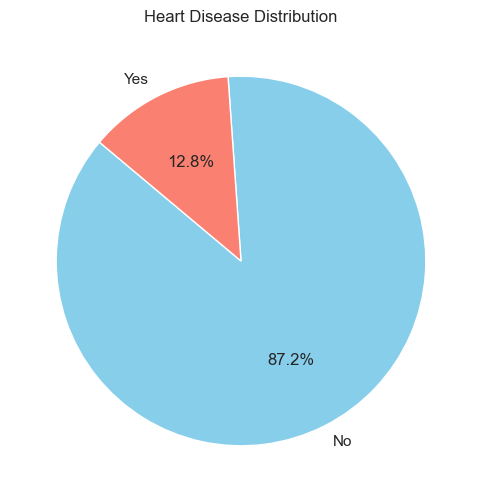

In [24]:
heart_counts = data['heart_disease'].value_counts()

#Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(heart_counts, labels=['No', 'Yes'], colors=['skyblue', 'salmon'], autopct='%1.1f%%', startangle=140)

plt.title('Heart Disease Distribution')
plt.show()

# Heart Disease and Stroke

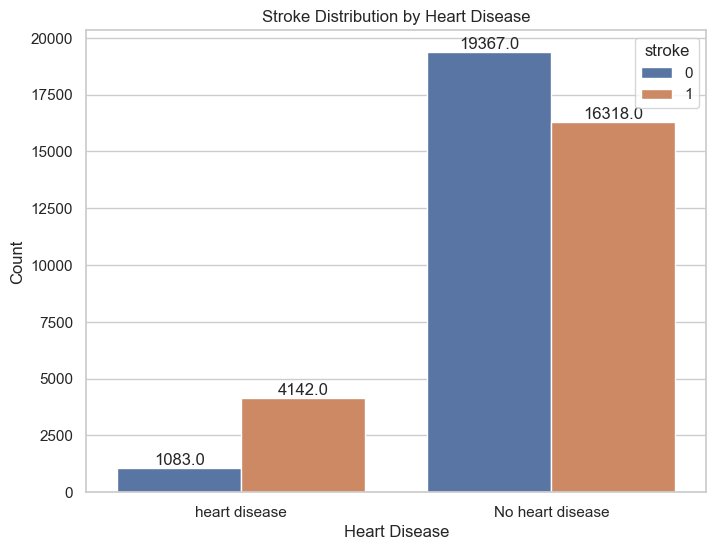

In [25]:
sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='heart_disease', hue='stroke', data=data) 

# Add counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

# plotting
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.title('Stroke Distribution by Heart Disease')
plt.show()

In [26]:
# calculate the mean of 'stroke' for each group
heart_stroke_mean = data.groupby('heart_disease')['stroke'].mean().sort_values()
print(heart_stroke_mean)

heart_disease
No heart disease    0.457279
heart disease       0.792727
Name: stroke, dtype: float64


# Smoking Status

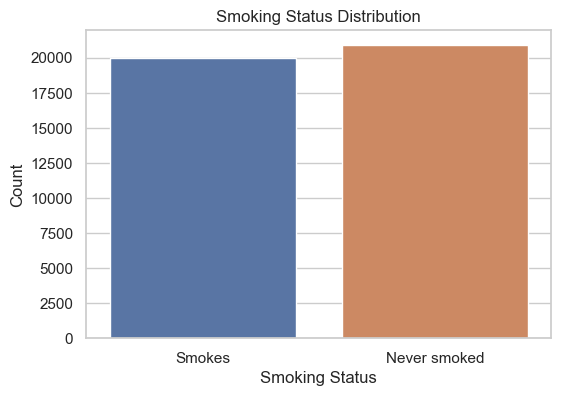

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='smoking_status', data=data)

# plotting
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Smoking Status Distribution')
plt.show()

# Smoking Status and Stroke

smoking_status
Never smoked    20921
Smokes          19989
Name: count, dtype: int64


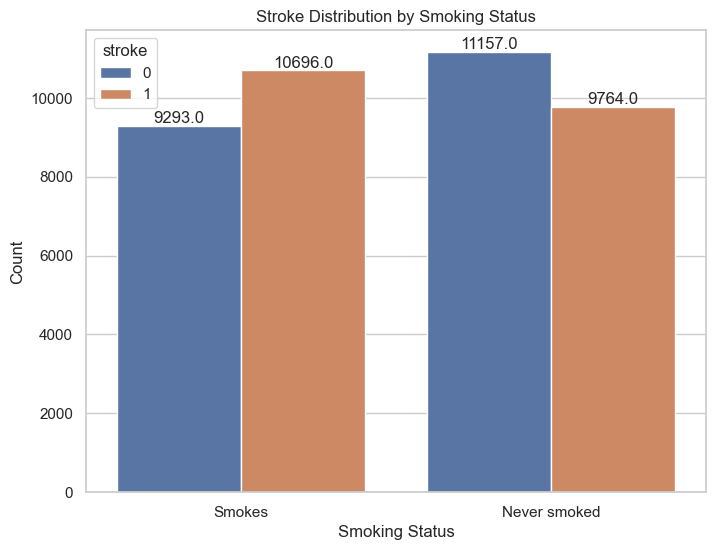

In [28]:
# counting
gender_counts = data['smoking_status'].value_counts()
print(gender_counts)

sns.set(style="whitegrid") 
plt.figure(figsize=(8, 6)) 
ax = sns.countplot(x='smoking_status', hue='stroke', data=data) 

# Add counts 
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')

# plotting
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Stroke Distribution by Smoking Status')
plt.show()

In [29]:
# calculate the mean of 'stroke' for each group
smoking_stroke_mean = data.groupby('smoking_status')['stroke'].mean().sort_values()
print(smoking_stroke_mean)

smoking_status
Never smoked    0.466708
Smokes          0.535094
Name: stroke, dtype: float64


# Age

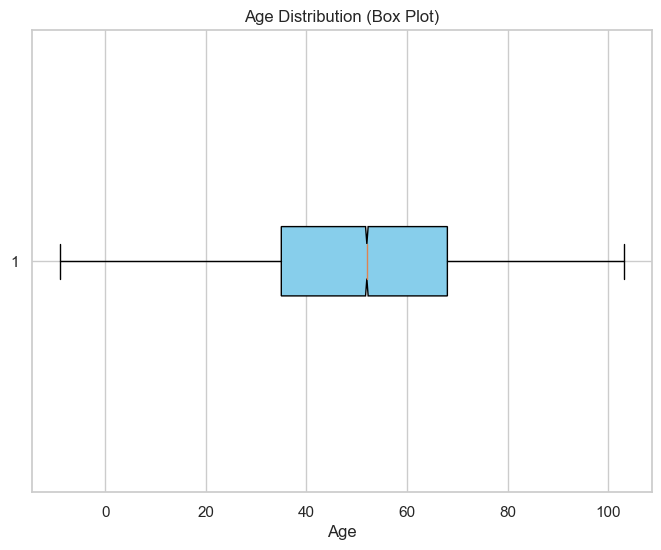

In [30]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data['age'], vert=False, notch=True, patch_artist=True, boxprops=dict(facecolor='skyblue', color='black'))

plt.xlabel('Age')
plt.title('Age Distribution (Box Plot)')
plt.show()

In [31]:
# There can not be negative age hence dropping these rows
data = data.drop(data[data.age < 0].index)
len(data. index)

40852

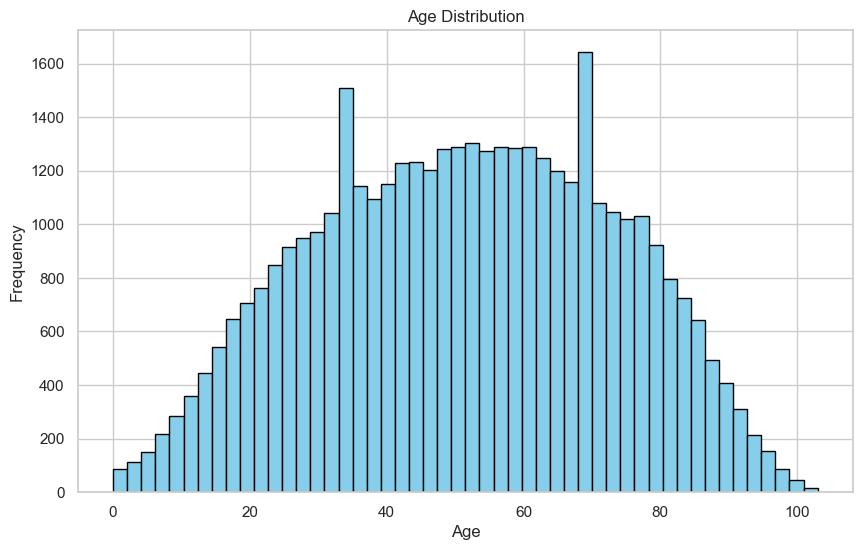

In [32]:
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(data['age'], bins=50, color='skyblue', edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

# Age and Stroke

C:\Users\Dellb\AppData\Local\Temp\ipykernel_8492\1979143685.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=stroke_data['age'], shade=True, label='Stroke', color='blue')
C:\Users\Dellb\AppData\Local\Temp\ipykernel_8492\1979143685.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=no_stroke_data['age'], shade=True, label='No Stroke', color='orange')


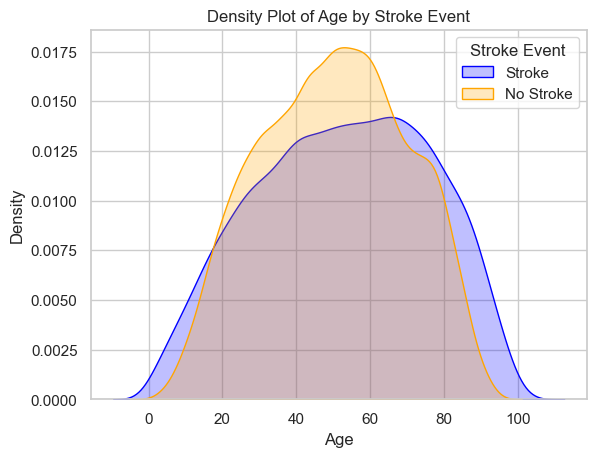

In [33]:
# separating stroke and no stroke events
stroke_data = data[data['stroke'] == 1]
no_stroke_data = data[data['stroke'] == 0]

# density plot for stroke and no stroke events
sns.kdeplot(data=stroke_data['age'], shade=True, label='Stroke', color='blue')
sns.kdeplot(data=no_stroke_data['age'], shade=True, label='No Stroke', color='orange')


plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Density Plot of Age by Stroke Event')
plt.legend(title='Stroke Event', labels=['Stroke', 'No Stroke'])
plt.show()

# Average Glucose Level

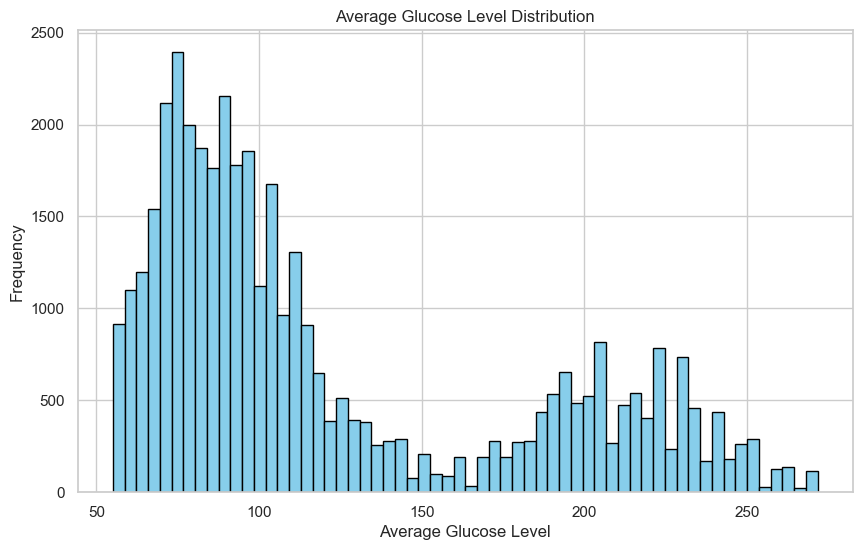

In [34]:
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(data['avg_glucose_level'], bins=60, color='skyblue', edgecolor='black')

plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.title('Average Glucose Level Distribution')
plt.show()

# Average Glucose Level and Stroke

C:\Users\Dellb\AppData\Local\Temp\ipykernel_8492\563377295.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=stroke_data['avg_glucose_level'], shade=True, label='Stroke', color='blue')
C:\Users\Dellb\AppData\Local\Temp\ipykernel_8492\563377295.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=no_stroke_data['avg_glucose_level'], shade=True, label='No Stroke', color='orange')


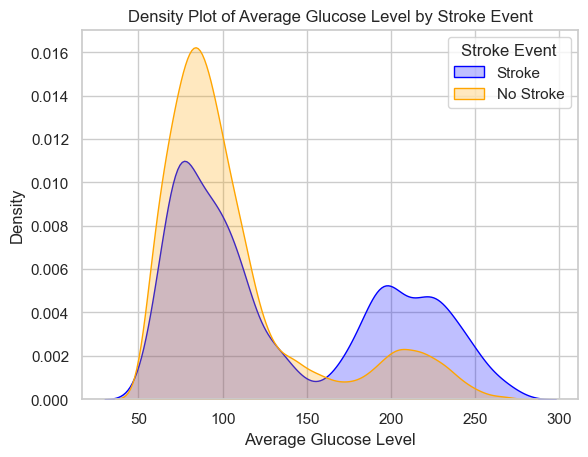

In [35]:
# separating stroke and no stroke events
stroke_data = data[data['stroke'] == 1]
no_stroke_data = data[data['stroke'] == 0]

# density plot for stroke events
sns.kdeplot(data=stroke_data['avg_glucose_level'], shade=True, label='Stroke', color='blue')

# density plot for no stroke events
sns.kdeplot(data=no_stroke_data['avg_glucose_level'], shade=True, label='No Stroke', color='orange')

plt.xlabel('Average Glucose Level')
plt.ylabel('Density')
plt.title('Density Plot of Average Glucose Level by Stroke Event')
plt.legend(title='Stroke Event', labels=['Stroke', 'No Stroke'])
plt.show()

# BMI

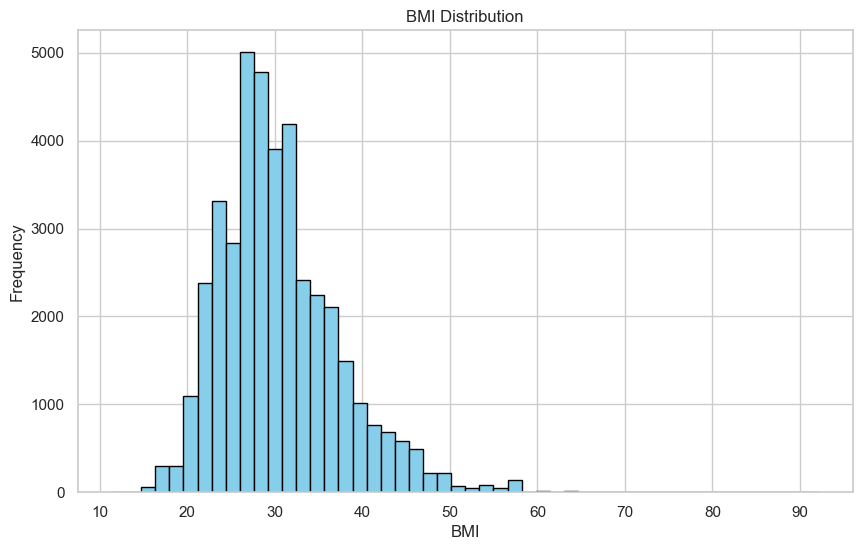

In [36]:
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(data['bmi'], bins=50, color='skyblue', edgecolor='black')

plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()

# BMI and Stroke

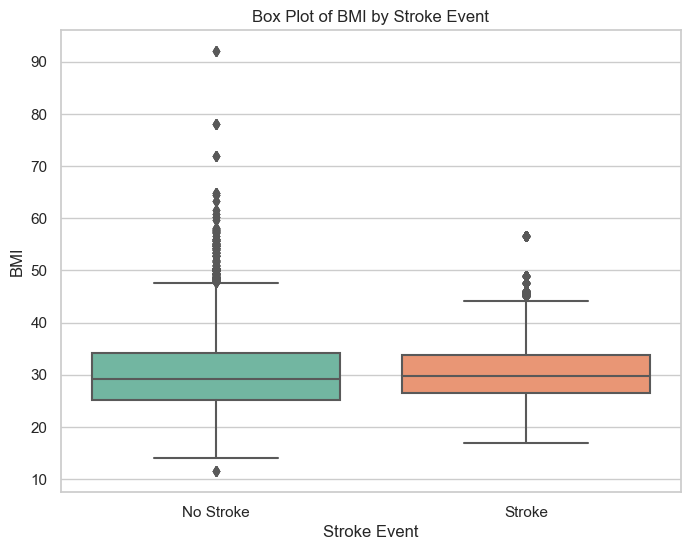

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='stroke', y='bmi', data=data, palette='Set2')

# Set labels and title
plt.xlabel('Stroke Event')
plt.ylabel('BMI')
plt.title('Box Plot of BMI by Stroke Event')

# Show the plot
plt.xticks(ticks=[0, 1], labels=['No Stroke', 'Stroke'])
plt.show()

# Stroke

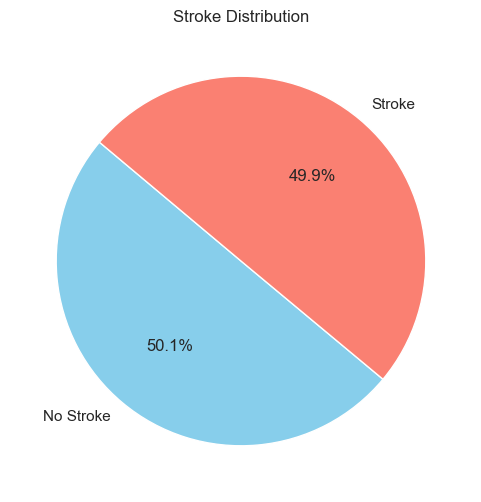

In [38]:
stroke_counts = data['stroke'].value_counts()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(stroke_counts, labels=['No Stroke', 'Stroke'], colors=['skyblue', 'salmon'], autopct='%1.1f%%', startangle=140)
plt.title('Stroke Distribution')
plt.show()

# 3. Preprocessing

# 3.1 Handling Missing Values

In [39]:
# Handling missing values in the 'gender' column
data['gender'].fillna('Female', inplace=True)  

# Rechecking for missing values in each column
print("Rechecking for missing values in each column:")
print(data.isnull().sum())

Rechecking for missing values in each column:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [40]:
# Deleting rows with work_type == Children & Never worked
data = data[(data['work_type'] != 'Children') & (data['work_type'] != 'Never worked')]

# 3.2 Feature Engineering

In [41]:
# Define BMI ranges and corresponding weight categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 24.9:
        return 'Normal'
    elif bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'
    
# Create the 'weight' variable
data['weight'] = data['bmi'].apply(categorize_bmi)

In [42]:
# Define age ranges and corresponding age group labels
def categorize_age(age):
    if age < 30:
        return 'Young'
    elif age < 60:
        return 'Middle-aged'
    else:
        return 'Elderly'
# Create the 'age_group' variable

data['age_group'] = data['age'].apply(categorize_age)

In [43]:
print(data.head(5))

   gender  age     hypertension     heart_disease ever_married      work_type  \
0    Male   63  No hypertension     heart disease          Yes        Private   
1    Male   42  No hypertension     heart disease          Yes        Private   
2  Female   61  No hypertension  No heart disease          Yes        Private   
3    Male   41     hypertension  No heart disease          Yes  Self-employed   
4    Male   85  No hypertension  No heart disease          Yes        Private   

  Residence_type  avg_glucose_level   bmi smoking_status  stroke      weight  \
0          Rural             228.69  36.6         Smokes       1       Obese   
1          Urban             105.92  32.5   Never smoked       1       Obese   
2          Rural             171.23  34.4         Smokes       1       Obese   
3          Urban             174.12  24.0   Never smoked       1      Normal   
4          Rural             186.21  29.0         Smokes       1  Overweight   

     age_group  
0      Elderly 

# 3.3 Label Encoding

In [44]:
# List of categorical variables to be label encoded
categorical_variables = data.select_dtypes(include=['object']).columns
print(categorical_variables)

# Create a dictionary to store the encoding mapping
encoding_mapping = {}

LE = LabelEncoder()

# Apply label encoding and store the mapping
for i in categorical_variables:
    data[i] = LE.fit_transform(data[i])
    # Store the mapping for each feature
    encoding_mapping[i] = dict(zip(LE.classes_, LE.transform(LE.classes_)))

# Print updated dataset
print(data.head())

# Print the mapping of encoded values back to their original labels
for feature, mapping in encoding_mapping.items():
    print(f"Mapping for {feature}: {mapping}")


Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'weight', 'age_group'],
      dtype='object')
   gender  age  hypertension  heart_disease  ever_married  work_type  \
0       1   63             0              1             1          1   
1       1   42             0              1             1          1   
2       0   61             0              0             1          1   
3       1   41             1              0             1          2   
4       1   85             0              0             1          1   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  weight  \
0               0             228.69  36.6               1       1       1   
1               1             105.92  32.5               0       1       1   
2               0             171.23  34.4               1       1       1   
3               1             174.12  24.0               0       1       0   
4        

# 3.4 Feature Selection using Heatmap

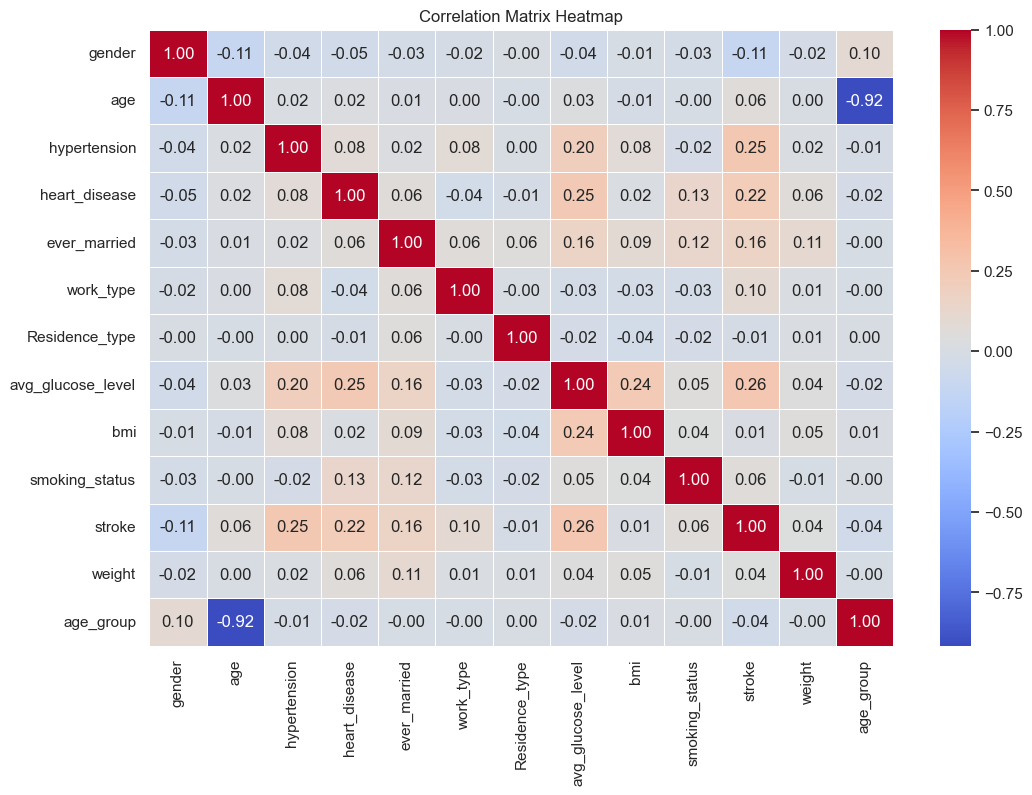

In [45]:
# Create the heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr('pearson'), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Annotations
plt.title('Correlation Matrix Heatmap')
plt.show()

# 3.5 Dropping Features

The threshold is 0.1.
Any feature with correlation less than 0.1 with the target variable will be dropped.

In [46]:
data_dropped = data.drop(['age', 'Residence_type', 'bmi', 'smoking_status', 'weight', 'age_group'], axis=1)

In [47]:
data_dropped.head(10)

,gender,hypertension,heart_disease,ever_married,work_type,avg_glucose_level,stroke
0,1,0,1,1,1,228.69,1
1,1,0,1,1,1,105.92,1
2,0,0,0,1,1,171.23,1
3,1,1,0,1,2,174.12,1
4,1,0,0,1,1,186.21,1
5,1,1,1,1,1,70.09,1
6,0,0,0,0,1,94.39,1
7,0,1,0,1,1,80.43,1
8,1,0,1,1,0,120.46,1
9,0,0,0,1,1,104.51,1


In [48]:
# number of unique values in each variables
print("Number of Unique Values in each variable.\n")
print(data_dropped.nunique())

Number of Unique Values in each variable.

gender                  2
hypertension            2
heart_disease           2
ever_married            2
work_type               3
avg_glucose_level    2853
stroke                  2
dtype: int64


# 3.6 Feature Scaling

In [49]:
# Scaling avg_glucose_level
sc = StandardScaler()
data_dropped[['avg_glucose_level']] = sc.fit_transform(data[['avg_glucose_level']])
data_dropped.head(10)

<IPython.core.display.Javascript object>

,gender,hypertension,heart_disease,ever_married,work_type,avg_glucose_level,stroke
0,1,0,1,1,1,1.841812,1
1,1,0,1,1,1,-0.284357,1
2,0,0,0,1,1,0.846702,1
3,1,1,0,1,2,0.896752,1
4,1,0,0,1,1,1.106130,1
5,1,1,1,1,1,-0.904872,1
6,0,0,0,0,1,-0.484037,1
7,0,1,0,1,1,-0.725800,1
8,1,0,1,1,0,-0.032548,1
9,0,0,0,1,1,-0.308775,1


# 4.Model Building and Evaluation

# Splitting the data

In [50]:
# Splitting features and target
X = data_dropped.drop('stroke', axis=1)
Y = data_dropped['stroke']

# Split the data into training and testing sets in ratio of 70:30
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Random Forest 

In [51]:
#Creating a base model Random Forest Classifier
rf_base_model = RandomForestClassifier(random_state=42)

# Evaluate the base model using 10-fold cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall']
results_base_model = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(rf_base_model, X_train, Y_train, cv=10, scoring=metric, n_jobs=-1)
    mean_score = np.mean(cv_scores)
    results_base_model[metric] = mean_score

# Defining range of hyperparameters for the coarse search
param_grid_coarse = {
    'n_estimators': [50, 100, 200], #number of trees in the forest
    'max_depth': [None, 10, 20], #max depth of trees
    'min_samples_split': [2, 5, 10], #min number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], #min number of leaves required a leaf node
    'max_features': ['auto', 'sqrt', 'log2'], #number of features to consider when looking for a split
}

# Initialize GridSearchCV with classifier and parameter grid
grid_search_coarse = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid_coarse,
    scoring='accuracy',  # scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the coarse grid search
grid_search_coarse.fit(X_train, Y_train) 

# Get the best hyperparameters from the coarse search
best_params_coarse = grid_search_coarse.best_params_
best_score_coarse = grid_search_coarse.best_score_

# Print the results
print("Best Hyperparameters (Coarse Search):", best_params_coarse)
print("Best Accuracy (Coarse Search):", best_score_coarse)

# Fine-tuning: Create a finer-grained parameter grid based on the coarse results
param_grid_fine = {
    'n_estimators': [best_params_coarse['n_estimators'] - 50, best_params_coarse['n_estimators'], best_params_coarse['n_estimators'] + 50],
    'max_depth': [best_params_coarse['max_depth'], best_params_coarse['max_depth'] + 10 if best_params_coarse['max_depth'] is not None else None],
    'min_samples_split': [best_params_coarse['min_samples_split']],
    'min_samples_leaf': [best_params_coarse['min_samples_leaf']],
    'max_features': ['auto', 'sqrt', 'log2'],
}

# Initialize GridSearchCV for fine-tuning
grid_search_fine = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid_fine,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the fine grid search
grid_search_fine.fit(X_train, Y_train)  

# Get the best hyperparameters from the fine search
best_params_fine = grid_search_fine.best_params_
best_score_fine = grid_search_fine.best_score_

# Print the results
print("Best Hyperparameters (Fine Search):", best_params_fine)
print("Best Accuracy (Fine Search):", best_score_fine)

# Evaluate the model using cross-validation
rf_classifier_best = RandomForestClassifier(
    random_state=42,
    **best_params_fine  # Use the best hyperparameters from fine-tuning
)

# Define the metrics you want to evaluate one at a time
scoring_metrics = ['accuracy', 'precision', 'recall']

# Initialize an empty dictionary to store the results
results = {}

# Loop through each scoring metric
for metric in scoring_metrics:
    # Perform cross-validation with the current metric
    cv_scores = cross_val_score(
        rf_classifier_best,
        X_train, Y_train,
        cv=10,
        scoring=metric,  # Evaluate using the current metric
        n_jobs=-1,
    )

    # Calculate and store the mean and standard deviation of the scores
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    # Store the results in the dictionary
    results[metric] = {'mean': mean_score, 'std': std_score}

# Print the results
print("Base Model Evaluation:")
for metric, score in results_base_model.items():
    print(f"{metric.capitalize()}: {score:.4f}")
    
print("\nBest Model Evaluation:")
for metric, scores in results.items():
    print(f"{metric.capitalize()} (Cross-Validation): {scores['mean']:.4f} +/- {scores['std']:.4f}")

Fitting 10 folds for each of 243 candidates, totalling 2430 fits


C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
810 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
431 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 637, in _validate_params
    validat

Best Hyperparameters (Coarse Search): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy (Coarse Search): 0.9964229357393084
Fitting 10 folds for each of 18 candidates, totalling 180 fits


C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
21 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_p

Best Hyperparameters (Fine Search): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy (Fine Search): 0.9964229357393084
Base Model Evaluation:
Accuracy: 0.9964
Precision: 0.9930
Recall: 1.0000

Best Model Evaluation:
Accuracy (Cross-Validation): 0.9964 +/- 0.0011
Precision (Cross-Validation): 0.9930 +/- 0.0021
Recall (Cross-Validation): 1.0000 +/- 0.0000


# Random Forest Precision-Recall Curve and ROC-Curve

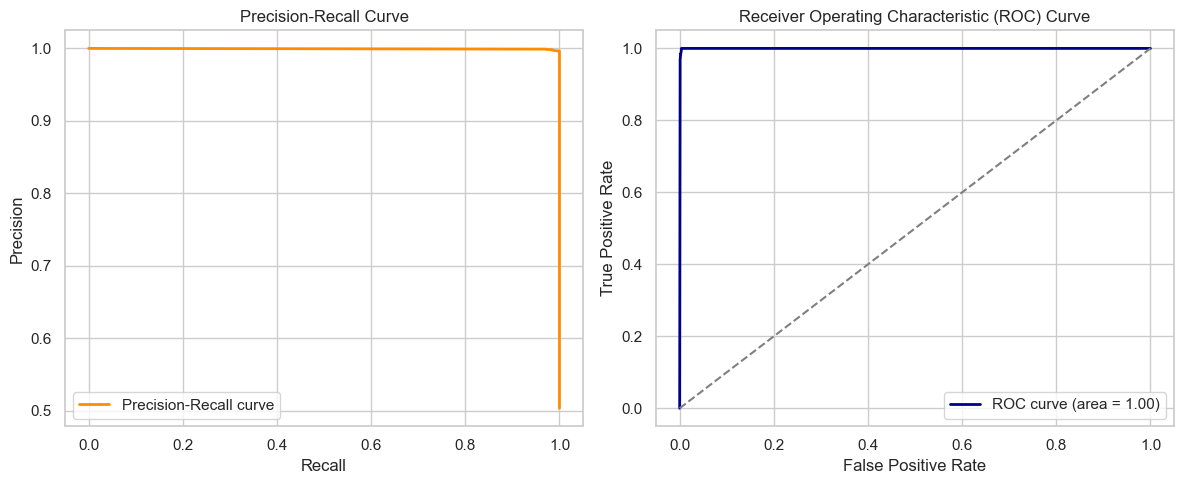

In [52]:
# Fit the model to your training data
rf_classifier_best.fit(X_train, Y_train)  

# Predict probabilities and labels on the test data
Y_pred_proba = rf_classifier_best.predict_proba(X_test)[:, 1]
Y_pred = rf_classifier_best.predict(X_test)

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, Y_pred_proba)

# Compute ROC curve
fpr, tpr, _ = roc_curve(Y_test, Y_pred_proba)

# Calculate AUC (Area Under Curve) for ROC
roc_auc = auc(fpr, tpr)

# Create subplots for Precision-Recall and ROC curves
plt.figure(figsize=(12, 5))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend(loc='best')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkblue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.grid(True)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# Random Forest Feature Importance

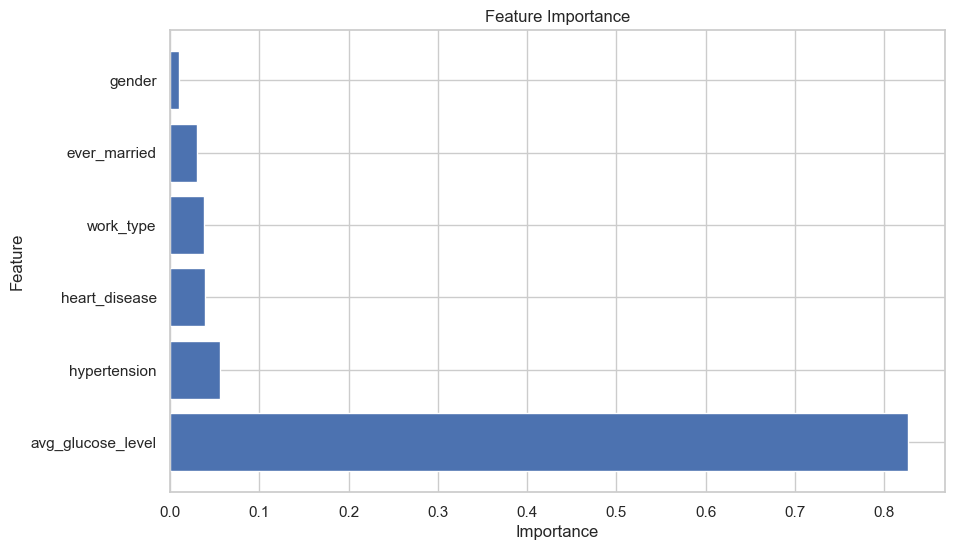

In [53]:
# Get feature importances from the best_estimator
feature_importances = rf_classifier_best.feature_importances_

# Create a DataFrame to associate feature names with their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Visualizing Random Forest

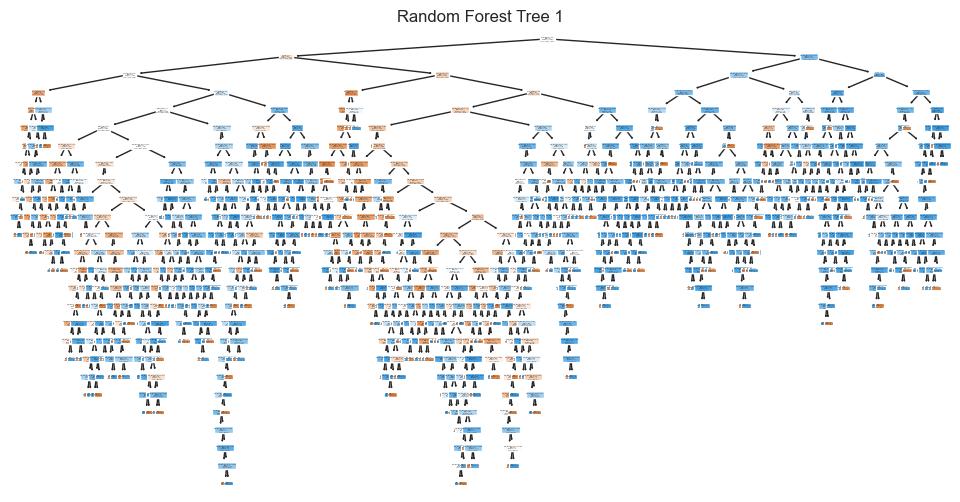

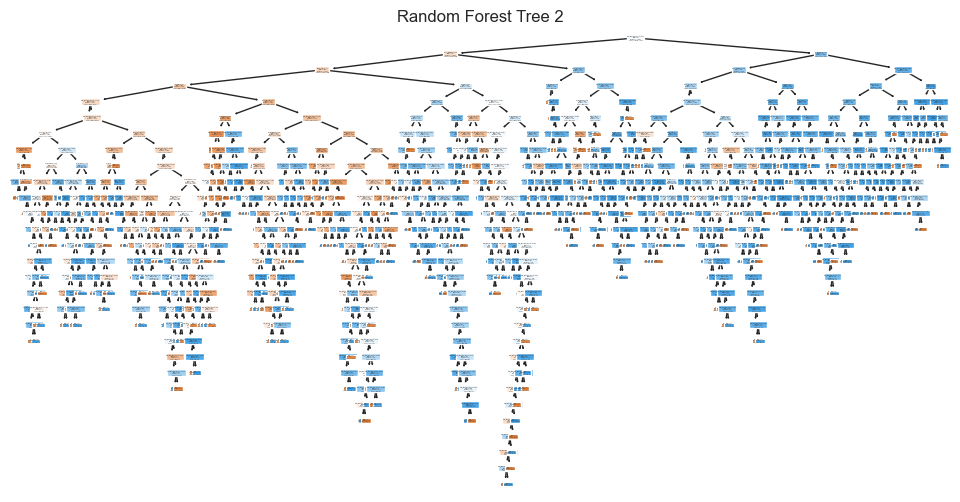

In [54]:
# Number of trees to visualize (change this as needed)
num_trees_to_visualize = 2

# Get the feature names from your dataset (replace 'X_train' with your actual training data)
feature_names = X_train.columns.tolist()

# Visualize the selected trees
for i in range(num_trees_to_visualize):
    # Plot the i-th tree
    plt.figure(figsize=(12, 6))
    plot_tree(rf_classifier_best.estimators_[i], filled=True, feature_names=feature_names)
    plt.title(f"Random Forest Tree {i+1}")
    plt.show()

# Decision Tree

In [55]:
#Creating a base model Decision Tree Classifier
dt_base_model = DecisionTreeClassifier(random_state=42)

# Evaluate the base model using 10-fold cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall']
results_base_model = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(dt_base_model, X_train, Y_train, cv=10, scoring=metric, n_jobs=-1)
    mean_score = np.mean(cv_scores)
    results_base_model[metric] = mean_score

# Defining range of hyperparameters for the coarse search
param_grid_coarse = {
    'splitter': ['best'], #stategy used to split at each node
    'max_depth': [None, 10, 20], #max depth of trees
    'min_samples_split': [2, 5, 10], #min number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 8], #min number of leaves required a leaf node
    'max_features': ['auto', 'sqrt', 'log2'], #number of features to consider when looking for a split
}

# Initialize GridSearchCV with classifier and parameter grid
grid_search_coarse = GridSearchCV(
    estimator=dt_base_model,
    param_grid=param_grid_coarse,
    scoring='accuracy',  # scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the coarse grid search
grid_search_coarse.fit(X_train, Y_train) 

# Get the best hyperparameters from the coarse search
best_params_coarse = grid_search_coarse.best_params_
best_score_coarse = grid_search_coarse.best_score_

# Print the results
print("Best Hyperparameters (Coarse Search):", best_params_coarse)
print("Best Accuracy (Coarse Search):", best_score_coarse)

# Fine-tuning: Create a finer-grained parameter grid based on the coarse results
param_grid_fine = {
    'splitter': [best_params_coarse['splitter']],
    'max_depth': [best_params_coarse['max_depth'], best_params_coarse['max_depth'] + 10 if best_params_coarse['max_depth'] is not None else None],
    'min_samples_split': [best_params_coarse['min_samples_split']],
    'min_samples_leaf': [best_params_coarse['min_samples_leaf']],
    'max_features': ['auto', 'sqrt', 'log2'],
}

# Initialize GridSearchCV for fine-tuning
grid_search_fine = GridSearchCV(
    estimator=dt_base_model,
    param_grid=param_grid_fine,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the fine grid search
grid_search_fine.fit(X_train, Y_train)  

# Get the best hyperparameters from the fine search
best_params_fine = grid_search_fine.best_params_
best_score_fine = grid_search_fine.best_score_

# Print the results
print("Best Hyperparameters (Fine Search):", best_params_fine)
print("Best Accuracy (Fine Search):", best_score_fine)

# Evaluate the model using cross-validation
dt_classifier_best = DecisionTreeClassifier(
    random_state=42,
    **best_params_fine  # Use the best hyperparameters from fine-tuning
)

# Define the metrics you want to evaluate one at a time
scoring_metrics = ['accuracy', 'precision', 'recall']

# Initialize an empty dictionary to store the results
results = {}

# Loop through each scoring metric
for metric in scoring_metrics:
    # Perform cross-validation with the current metric
    cv_scores = cross_val_score(
        dt_classifier_best,
        X_train, Y_train,
        cv=10,
        scoring=metric,  # Evaluate using the current metric
        n_jobs=-1,
    )

    # Calculate and store the mean and standard deviation of the scores
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    # Store the results in the dictionary
    results[metric] = {'mean': mean_score, 'std': std_score}

# Print the results
print("Base Model Evaluation:")
for metric, score in results_base_model.items():
    print(f"{metric.capitalize()}: {score:.4f}")
    
print("\nBest Model Evaluation:")
for metric, scores in results.items():
    print(f"{metric.capitalize()} (Cross-Validation): {scores['mean']:.4f} +/- {scores['std']:.4f}")

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
360 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
115 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 637, in _validate_params
    validat

Best Hyperparameters (Coarse Search): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best Accuracy (Coarse Search): 0.9967062845766111
Fitting 10 folds for each of 6 candidates, totalling 60 fits


C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
13 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_pa

Best Hyperparameters (Fine Search): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best Accuracy (Fine Search): 0.9967062845766111
Base Model Evaluation:
Accuracy: 0.9984
Precision: 0.9968
Recall: 1.0000

Best Model Evaluation:
Accuracy (Cross-Validation): 0.9967 +/- 0.0009
Precision (Cross-Validation): 0.9935 +/- 0.0018
Recall (Cross-Validation): 1.0000 +/- 0.0000


# Visualizing the Decision Tree

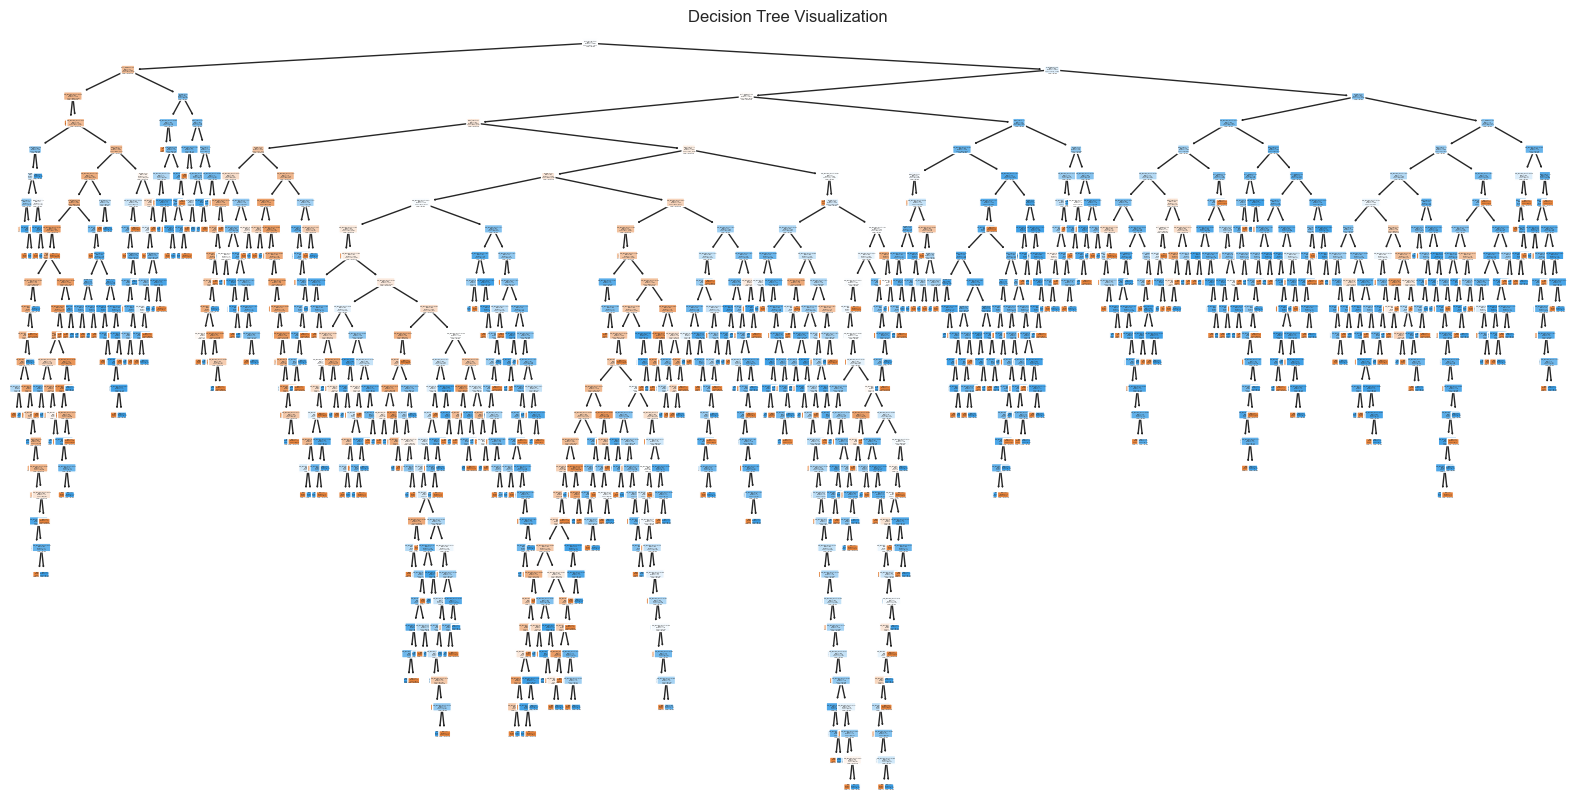

Decision Tree Rules:
|--- ever_married <= 0.50
|   |--- heart_disease <= 0.50
|   |   |--- avg_glucose_level <= -0.98
|   |   |   |--- class: 0
|   |   |--- avg_glucose_level >  -0.98
|   |   |   |--- avg_glucose_level <= -0.94
|   |   |   |   |--- hypertension <= 0.50
|   |   |   |   |   |--- gender <= 0.50
|   |   |   |   |   |   |--- work_type <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- work_type >  1.50
|   |   |   |   |   |   |   |--- avg_glucose_level <= -0.95
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- avg_glucose_level >  -0.95
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- gender >  0.50
|   |   |   |   |   |   |--- work_type <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- work_type >  1.50
|   |   |   |   |   |   |   |--- avg_glucose_level <= -0.95
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- avg_glucose_level >  -0.95


In [56]:
# Visualize the Decision Tree
dt_classifier_best.fit(X_train, Y_train)
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier_best, feature_names=X_train.columns.tolist(), class_names=['No Stroke', 'Stroke'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# The if-else rules of the decision tree
tree_rules = export_text(dt_classifier_best, feature_names=X_train.columns.tolist())

print("Decision Tree Rules:")
print(tree_rules)

# Decision Tree Precision-Recall Curve and ROC Curve

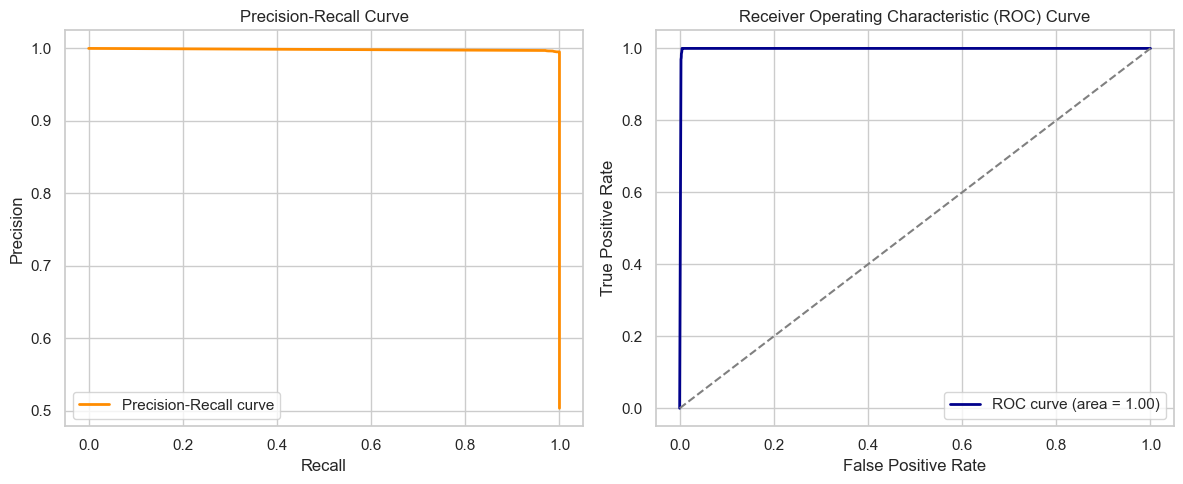

In [57]:
# Fit the model to your training data
dt_classifier_best.fit(X_train, Y_train)  

# Predict probabilities and labels on the test data
Y_pred_proba = dt_classifier_best.predict_proba(X_test)[:, 1]
Y_pred = dt_classifier_best.predict(X_test)

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, Y_pred_proba)

# Compute ROC curve
fpr, tpr, _ = roc_curve(Y_test, Y_pred_proba)

# Calculate AUC (Area Under Curve) for ROC
roc_auc = auc(fpr, tpr)

# Create subplots for Precision-Recall and ROC curves
plt.figure(figsize=(12, 5))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend(loc='best')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkblue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.grid(True)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# Decision Tree Feature Importance

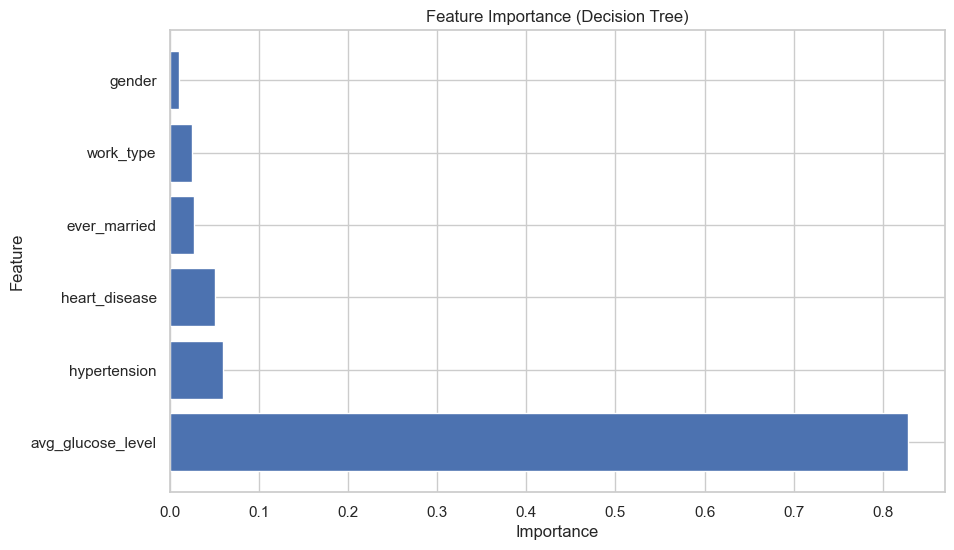

In [58]:
# Fitting
dt_classifier_best.fit(X_train, Y_train)

# Get feature importances from the trained Decision Tree model
feature_importances = dt_classifier_best.feature_importances_

# Create a DataFrame to associate feature names with their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Decision Tree)')
plt.show()

# Exporting the Decision Tree

In [59]:
# Export the Decision Tree to a DOT format
dot_data = export_graphviz(
    dt_classifier_best, 
    out_file=None, 
    feature_names=X_train.columns.tolist(), 
    class_names=['No Stroke', 'Stroke'],
    filled=True,
    rounded=True
)

# Create a Graphviz object from the DOT data
graph = graphviz.Source(dot_data)

# Save the visualization as an PNG file
graph.format = 'png'
graph.render("decision_tree_visualization")

graph.view()

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.759832 to fit
dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.759832 to fit


'decision_tree_visualization.png'

# XGBoost

In [60]:
# Import XGBClassifier from the XGBoost library
from xgboost import XGBClassifier

#Creating a base model XGBClassifier
xgb_classifier = XGBClassifier(random_state=42)

# Evaluate the base model using 10-fold cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall']
results_base_model = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(xgb_classifier, X_train, Y_train, cv=10, scoring=metric, n_jobs=-1)
    mean_score = np.mean(cv_scores)
    results_base_model[metric] = mean_score

# Define your range of hyperparameters for the coarse search
param_grid_coarse = {
    'n_estimators': [100, 200, 300], # number of trees
    'max_depth': [3, 4, 5], # Increasing this value will make the model more complex and more likely to overfit
    'learning_rate': [0.01, 0.1, 0.2], # to slow down learning rate to avoid overfitting
    'min_child_weight': [1, 2, 4],#minimum sum of weights of all observations required in a child. Used to control over-fitting. Higher values prevent a model from learning relations that might be highly specific to the particular sample selected for a tree. Too high values can lead to under-fitting;
    'gamma': [0, 0.1, 0.2], #A node is split only when the resulting split gives a positive reduction in the loss function. Gamma specifies the minimum loss reduction required to make a split.Makes the algorithm conservative.
}


# Initialize GridSearchCV with your classifier and parameter grid for the coarse search
grid_search_coarse = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid_coarse,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the coarse grid search
grid_search_coarse.fit(X_train, Y_train)  # Replace with your data

# Get the best hyperparameters from the coarse search
best_params_coarse = grid_search_coarse.best_params_
best_score_coarse = grid_search_coarse.best_score_

# Print the results
print("Best Hyperparameters (Coarse Search):", best_params_coarse)
print("Best Accuracy (Coarse Search):", best_score_coarse)

# Fine-tuning: Create a finer-grained parameter grid based on the coarse results
param_grid_fine = {
    'n_estimators': [best_params_coarse['n_estimators'] - 50, best_params_coarse['n_estimators'], best_params_coarse['n_estimators'] + 50],
    'max_depth': [best_params_coarse['max_depth'], best_params_coarse['max_depth'] + 1, best_params_coarse['max_depth'] + 2],
    'learning_rate': [best_params_coarse['learning_rate'] * 0.1, best_params_coarse['learning_rate'], best_params_coarse['learning_rate'] * 2],
    'min_child_weight': [best_params_coarse['min_child_weight'] - 1, best_params_coarse['min_child_weight'], best_params_coarse['min_child_weight'] + 1],
    'gamma': [best_params_coarse['gamma'] - 0.1, best_params_coarse['gamma'], best_params_coarse['gamma'] + 0.1],
}

# Initialize GridSearchCV for fine-tuning
grid_search_fine = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid_fine,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the fine grid search
grid_search_fine.fit(X_train, Y_train)  

# Get the best hyperparameters from the fine search
best_params_fine = grid_search_fine.best_params_
best_score_fine = grid_search_fine.best_score_

# Print the results
print("Best Hyperparameters (Fine Search):", best_params_fine)
print("Best Accuracy (Fine Search):", best_score_fine)

# Evaluate the model using cross-validation
xgb_classifier_best = XGBClassifier(
    random_state=42,
    **best_params_fine  
)

# Define the metrics you want to evaluate one at a time
scoring_metrics = ['accuracy', 'precision', 'recall']

# Initialize an empty dictionary to store the results
results = {}

# Loop through each scoring metric
for metric in scoring_metrics:
    cv_scores = cross_val_score(
        xgb_classifier_best,
        X_train, Y_train,
        cv=10,
        scoring=metric,  
        n_jobs=-1,
    )

    # Calculate and store the mean and standard deviation of the scores
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    # Store the results in the dictionary
    results[metric] = {'mean': mean_score, 'std': std_score}

# Print the results
print("Base Model Evaluation:")
for metric, score in results_base_model.items():
    print(f"{metric.capitalize()}: {score:.4f}")
    
# Print the results
print("Best Model Evaluation:")
for metric, scores in results.items():
    print(f"{metric.capitalize()} (Cross-Validation): {scores['mean']:.4f} +/- {scores['std']:.4f}")

Fitting 10 folds for each of 243 candidates, totalling 2430 fits
Best Hyperparameters (Coarse Search): {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300}
Best Accuracy (Coarse Search): 0.9944041834626335
Fitting 10 folds for each of 243 candidates, totalling 2430 fits


C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
810 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
810 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py", line 620, in inner_f
    return func(**kwargs)
  File "C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\xgboost\sklearn.py", line 1490, in fit
    self._Booster = train(
 

Best Hyperparameters (Fine Search): {'gamma': 0, 'learning_rate': 0.4, 'max_depth': 6, 'min_child_weight': 0, 'n_estimators': 250}
Best Accuracy (Fine Search): 0.9985833185318091
Base Model Evaluation:
Accuracy: 0.9913
Precision: 0.9830
Recall: 1.0000
Best Model Evaluation:
Accuracy (Cross-Validation): 0.9986 +/- 0.0006
Precision (Cross-Validation): 0.9972 +/- 0.0012
Recall (Cross-Validation): 1.0000 +/- 0.0000


# XGBoost Precision-Recall Curve and ROC Curve

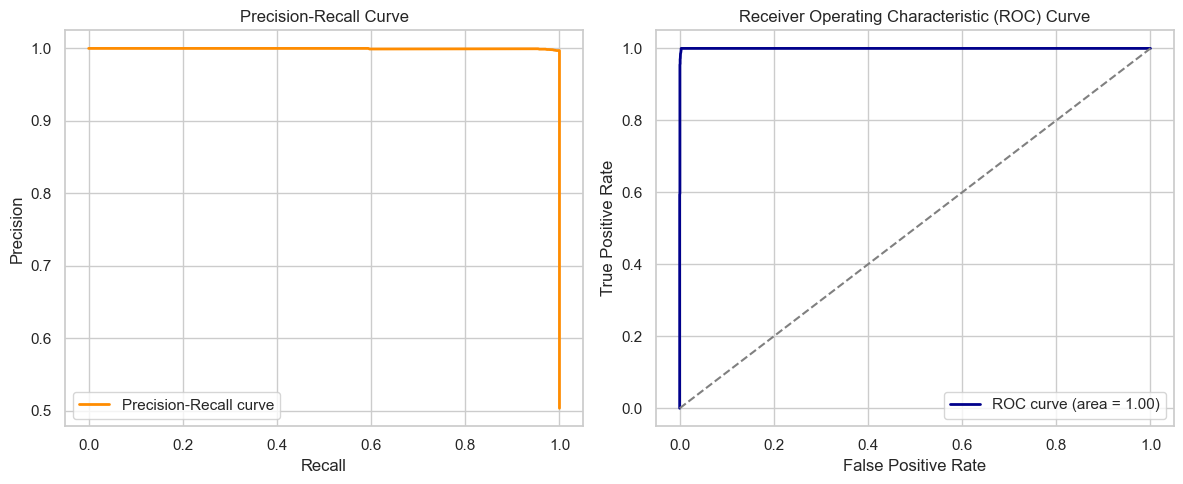

In [61]:
# Fit the model to your training data using the best hyperparameters
xgb_classifier_best.fit(X_train, Y_train)  

# Predict probabilities and labels on the test data
Y_pred_proba = xgb_classifier_best.predict_proba(X_test)[:, 1]
Y_pred = xgb_classifier_best.predict(X_test)

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, Y_pred_proba)

# Compute ROC curve
fpr, tpr, _ = roc_curve(Y_test, Y_pred_proba)

# Calculate AUC (Area Under Curve) for ROC
roc_auc = auc(fpr, tpr)

# Create subplots for Precision-Recall and ROC curves
plt.figure(figsize=(12, 5))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend(loc='best')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkblue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.grid(True)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# XGBoost Feature Importance

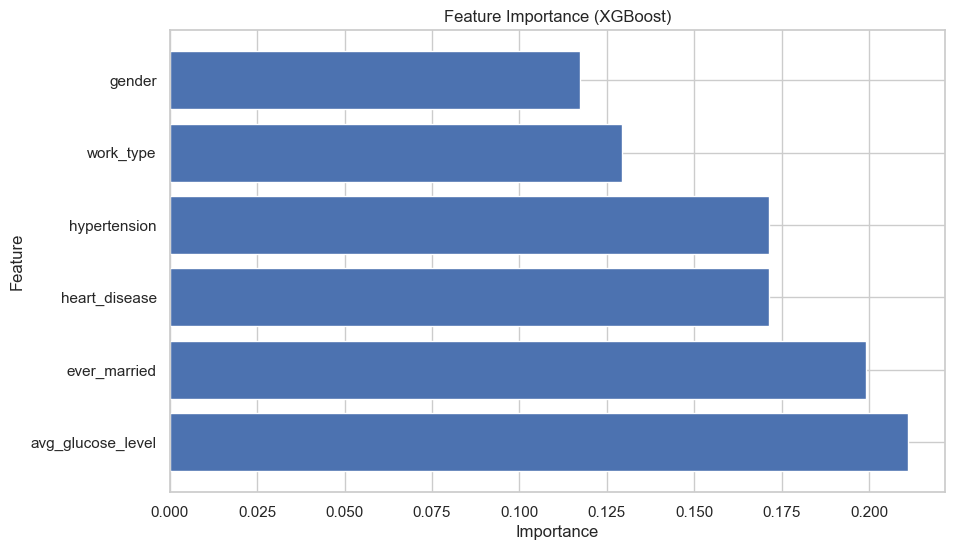

In [62]:
# Fit the XGBoost model on the training data
xgb_classifier_best.fit(X_train, Y_train)

# Get feature importances from the trained XGBoost model
feature_importances = xgb_classifier_best.feature_importances_

# Create a DataFrame to associate feature names with their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (XGBoost)')
plt.show()

# LightBGM

In [63]:
# Creating a base LightGBM Classifier
lgb_classifier = lgb.LGBMClassifier(random_state=42)

# Evaluate the base model using 10-fold cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall']
results_base_model = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(lgb_classifier, X_train, Y_train, cv=10, scoring=metric, n_jobs=-1)
    mean_score = np.mean(cv_scores)
    results_base_model[metric] = mean_score
    
# Define your range of hyperparameters for the coarse search
param_grid_coarse = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 4, 5, 6],       # Max depth of trees
    'learning_rate': [0.01, 0.1, 0.2],  # Learning rate 
    'min_child_weight': [1, 2, 4],    # Minimum sum of instance weight  needed in a child
}

# Initialize GridSearchCV with your classifier and parameter grid for the coarse search
grid_search_coarse = GridSearchCV(
    estimator=lgb_classifier,
    param_grid=param_grid_coarse,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the coarse grid search
grid_search_coarse.fit(X_train, Y_train)  # Replace with your data

# Get the best hyperparameters from the coarse search
best_params_coarse = grid_search_coarse.best_params_
best_score_coarse = grid_search_coarse.best_score_

# Print the results
print("Best Hyperparameters (Coarse Search):", best_params_coarse)
print("Best Accuracy (Coarse Search):", best_score_coarse)

# Fine-tuning: Create a finer-grained parameter grid based on the coarse results
param_grid_fine = {
    'n_estimators': [best_params_coarse['n_estimators'] - 50, best_params_coarse['n_estimators'], best_params_coarse['n_estimators'] + 50],
    'max_depth': [best_params_coarse['max_depth'], best_params_coarse['max_depth'] + 1, best_params_coarse['max_depth'] + 2],
    'learning_rate': [best_params_coarse['learning_rate'] * 0.1, best_params_coarse['learning_rate'], best_params_coarse['learning_rate'] * 2],
    'min_child_weight': [best_params_coarse['min_child_weight'] - 1, best_params_coarse['min_child_weight'], best_params_coarse['min_child_weight'] + 1],
}

# Initialize GridSearchCV for fine-tuning
grid_search_fine = GridSearchCV(
    estimator=lgb_classifier,
    param_grid=param_grid_fine,
    scoring='accuracy',  # You can change the scoring metric
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,
)

# Perform the fine grid search
grid_search_fine.fit(X_train, Y_train)  # Replace with your data

# Get the best hyperparameters from the fine search
best_params_fine = grid_search_fine.best_params_
best_score_fine = grid_search_fine.best_score_

# Print the results
print("Best Hyperparameters (Fine Search):", best_params_fine)
print("Best Accuracy (Fine Search):", best_score_fine)

# Initialize the final LightGBM model with the best hyperparameters
lgb_classifier_best = lgb.LGBMClassifier(
    random_state=42,
    **best_params_fine  # Use the best hyperparameters from fine-tuning
)

# Perform cross-validation for accuracy, precision, and recall
scoring_metrics = ['accuracy', 'precision', 'recall']
results = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(
        lgb_classifier_best,
        X_train, Y_train,
        cv=10,
        scoring=metric,
        n_jobs=-1,
    )

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    results[metric] = {'mean': mean_score, 'std': std_score}

# Print the results
print("Base Model Evaluation:")
for metric, score in results_base_model.items():
    print(f"{metric.capitalize()}: {score:.4f}")
    
# Print the results
for metric, scores in results.items():
    print(f"{metric.capitalize()} (Cross-Validation): {scores['mean']:.4f} +/- {scores['std']:.4f}")

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14314, number of negative: 13921
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 28235, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506959 -> initscore=0.027840
[LightGBM] [Info] Start training from score 0.027840
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14314, number of negative: 13921
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 28235, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506959 -> initscore=0.027840
[LightGBM] [Info] Start training from score 0.027840
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

# LightBGM Precision-Recall Curve and ROC Curve

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14314, number of negative: 13921
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 28235, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506959 -> initscore=0.027840
[LightGBM] [Info] Start training from score 0.027840
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

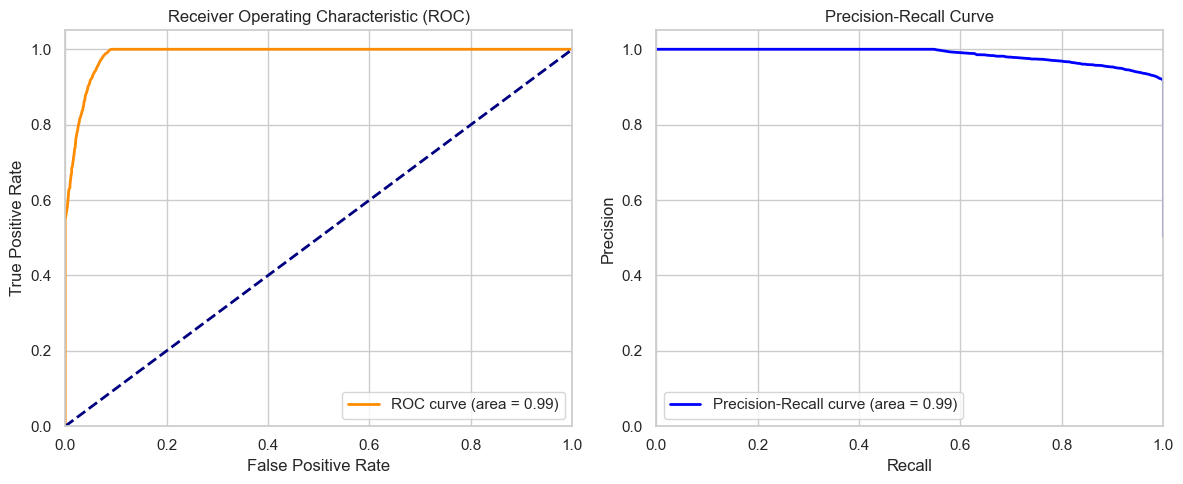

In [64]:
# Fit the LightGBM classifier on your training data
lgb_classifier_best.fit(X_train, Y_train)

# Get predicted probabilities for the positive class
Y_prob = lgb_classifier_best.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve values
precision, recall, _ = precision_recall_curve(Y_test, Y_prob)

# Calculate ROC curve values
fpr, tpr, _ = roc_curve(Y_test, Y_prob)

# Calculate area under the curves (AUC)
roc_auc = auc(fpr, tpr)
pr_auc = auc(recall, precision)

# Plot ROC curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')

# Plot Precision-Recall curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# LightBGM Feature Importance

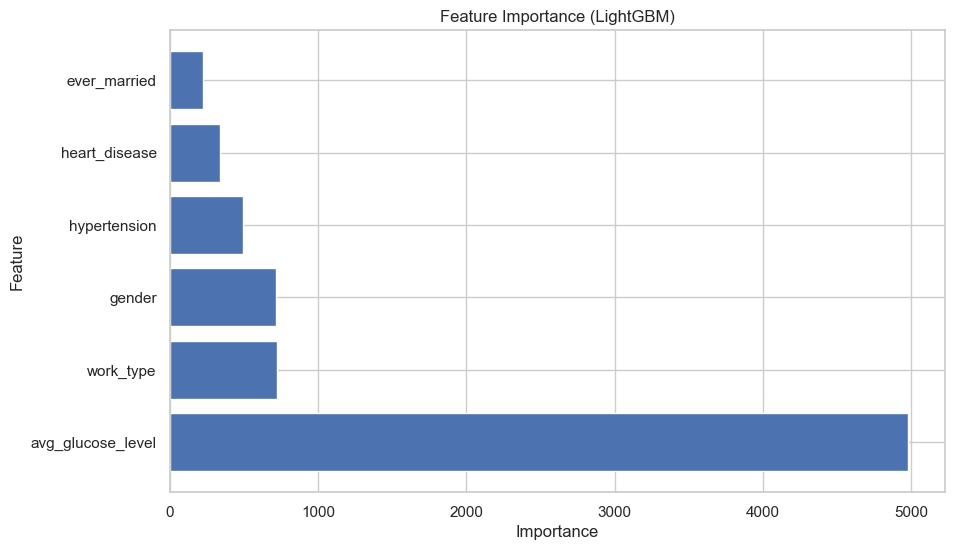

In [65]:
# Get feature importances from the trained LightGBM model
feature_importances = lgb_classifier_best.feature_importances_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame to associate feature names with their importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (LightGBM)')
plt.show()

# Choosing the Best Model

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14314, number of negative: 13921
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 28235, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506959 -> initscore=0.027840
[LightGBM] [Info] Start training from score 0.027840
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

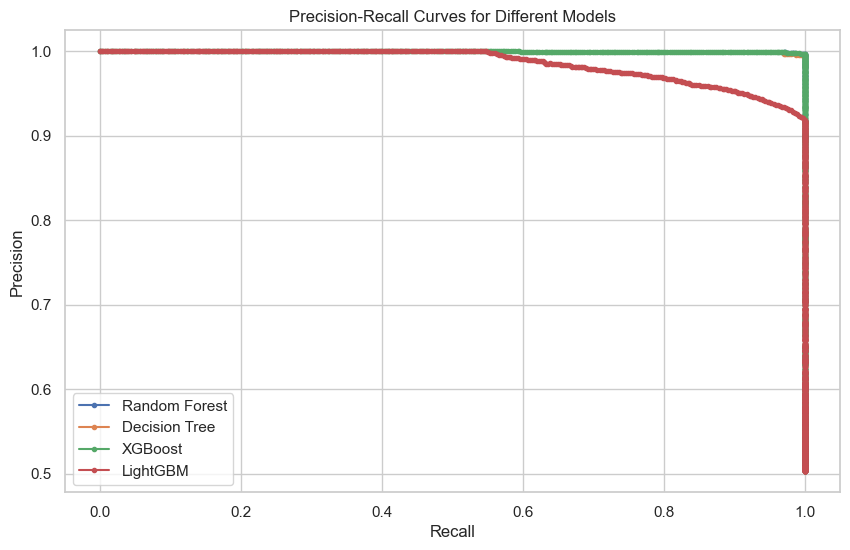

In [66]:
# List of models and their corresponding names
models = [rf_classifier_best, dt_classifier_best, xgb_classifier_best, lgb_classifier_best]
model_names = ['Random Forest', 'Decision Tree', 'XGBoost', 'LightGBM']

plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    # Fit the model
    model.fit(X_train, Y_train)
    
    # Predict probabilities
    Y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate precision and recall
    precision, recall, _ = precision_recall_curve(Y_test, Y_probs)
    
    # Plot Precision-Recall curve
    plt.plot(recall, precision, marker='.', label=model_names[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.show()

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14314, number of negative: 13921
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 259
[LightGBM] [Info] Number of data points in the train set: 28235, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506959 -> initscore=0.027840
[LightGBM] [Info] Start training from score 0.027840
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

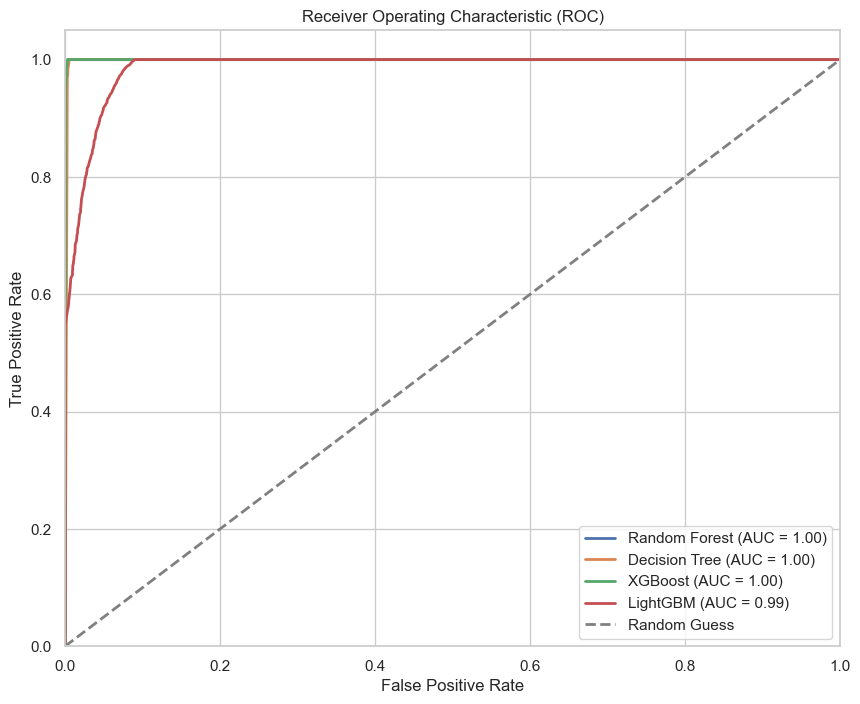

In [67]:
classifiers = {
    'Random Forest': rf_classifier_best,
    'Decision Tree': dt_classifier_best,
    'XGBoost': xgb_classifier_best,
    'LightGBM': lgb_classifier_best
}

# Create a figure and axis for the ROC curve
plt.figure(figsize=(10, 8))

# Loop through each classifier
for name, classifier in classifiers.items():
    # Fit the classifier on the training data
    classifier.fit(X_train, Y_train)
    
    # Get predicted probabilities for class 1
    if hasattr(classifier, "predict_proba"):
        y_score = classifier.predict_proba(X_test)[:, 1]
    else:
        y_score = classifier.decision_function(X_test)
    
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(Y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve for the current classifier
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [68]:
from sklearn.metrics import confusion_matrix

# Create a list of classifiers
classifiers = [dt_classifier_best, rf_classifier_best, xgb_classifier_best, lgb_classifier_best]
classifier_names = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM"]

for classifier, name in zip(classifiers, classifier_names):
    # Predict labels on the test data
    Y_pred = classifier.predict(X_test)
    
    # Generate the confusion matrix
    confusion_mat = confusion_matrix(Y_test, Y_pred)

    print(f"{name} Confusion Matrix:\n", confusion_mat)


Decision Tree Confusion Matrix:
 [[5984   29]
 [   0 6088]]
Random Forest Confusion Matrix:
 [[5987   26]
 [   0 6088]]
XGBoost Confusion Matrix:
 [[5995   18]
 [   0 6088]]
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
LightGBM Confusion Matrix:
 [[5470  543]
 [   0 6088]]


# Checking for Fitting by Plotting Learning Curves

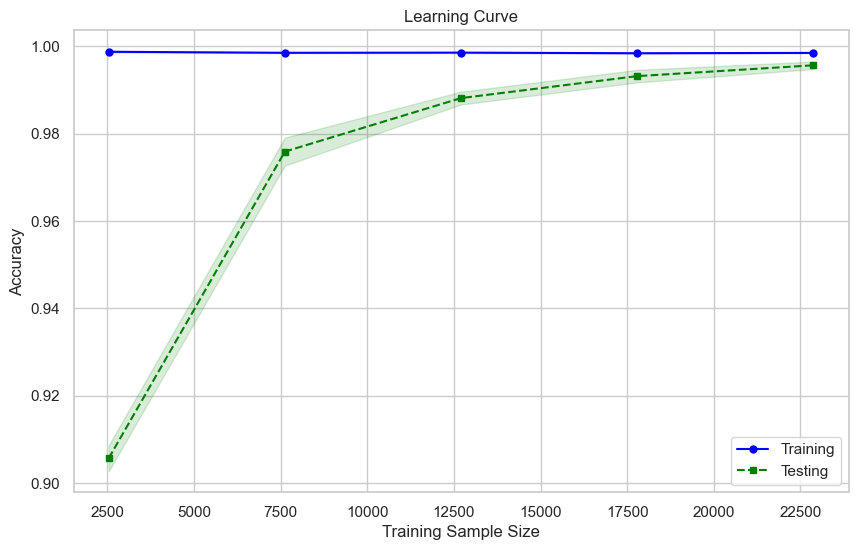

In [69]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]

# Create a learning curve
train_sizes, train_scores, test_scores = learning_curve(
    dt_classifier_best,  # Decision Tree classifier
    X_train, Y_train,
    train_sizes=train_sizes,
    cv=10,  # 10-fold cross-validation
    scoring='accuracy',  # scoring metric
    n_jobs=-1,
)

# Calculate the mean and standard deviation of training and testing scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Create the learning curve plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Testing')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
plt.title('Learning Curve')
plt.xlabel('Training Sample Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Testing the Decision Tree Model 

In [70]:
# Make predictions using the trained Decision Tree classifier
predictions = dt_classifier_best.predict(X_test)

# Create a pandas Series for labels
y_actual = pd.Series(Y_test, name='Actual')
results_df = pd.DataFrame({'Actual': y_actual, 'Predicted': predictions})

print(results_df.head(50))

       Actual  Predicted
21633       0          0
6324        1          1
36978       0          0
9356        1          1
6809        1          1
24172       0          0
465         1          1
22694       0          0
22474       0          0
21875       0          0
36131       0          0
29760       0          0
15354       1          1
15799       1          1
13138       1          1
10438       1          1
39028       0          0
12631       1          1
625         1          1
3102        1          1
39687       0          0
25159       0          0
15731       1          1
19282       1          1
22994       0          0
33914       0          0
1503        1          1
7117        1          1
9596        1          1
21171       0          0
22974       0          0
11626       1          1
33746       0          0
16659       1          1
26550       0          0
27021       0          0
13103       1          1
21083       0          0
1682        1          1


# Model Deployment

In [94]:
# Saving the model
import joblib

filename = "DecisionTree_model.joblib"
joblib.dump(dt_classifier_best, filename)

['DecisionTree_model.joblib']

# Model Explainability using Shapash

In [102]:
from shapash.explainer.smart_explainer import SmartExplainer

model = dt_classifier_best  

features_dict={
        "feature1": "Description of feature 1",
        "feature2": "Description of feature 2",
    }

xpl = SmartExplainer(model=model)
xpl.compile(
    x=X_test,
    y_pred=y_pred_series,
    y_target=Y_test
)

In [103]:
# Start the Web App
app = xpl.run_app(title_story="Stroke Predicition")

C:\Users\Dellb\AppData\Roaming\Python\Python39\site-packages\shapash\webapp\utils\utils.py:41: FutureWarning:

Index.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead

INFO:root:Your Shapash application run on http://Jaykishan:8050/
INFO:root:Use the method .kill() to down your app.
Exception in thread Thread-180:
Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\envs\MachineLearning\lib\site-packages\urllib3\connection.py", line 174, in _new_conn
    conn = connection.create_connection(
  File "C:\ProgramData\Anaconda3\envs\MachineLearning\lib\site-packages\urllib3\util\connection.py", line 95, in create_connection
    raise err
  File "C:\ProgramData\Anaconda3\envs\MachineLearning\lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    sock.connect(sa)
OSError: [WinError 10049] The requested address is not valid in its context

During handling of the above exception, another exception occurred:

Traceback (most

In [74]:
# To kill the App
app.kill()

In [75]:
# To Export the Local Explanations in a Dataframe
summary = xpl.to_pandas(
    max_contrib = 6, #the number of features to show in summary
)

summary.head(5)

,pred,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2,feature_3,value_3,contribution_3,feature_4,value_4,contribution_4,feature_5,value_5,contribution_5,feature_6,value_6,contribution_6
21633,0,avg_glucose_level,1.118946,0.482903,hypertension,1.0,-0.096871,ever_married,1.0,0.055889,work_type,1.0,0.032481,heart_disease,0.0,0.018729,gender,1.0,0.013827
6324,1,hypertension,1.0,0.380278,avg_glucose_level,-0.904872,-0.17456,work_type,1.0,0.133319,heart_disease,1.0,0.100989,ever_married,1.0,0.05691,gender,0.0,-0.003895
36978,0,avg_glucose_level,-0.282625,0.403274,heart_disease,0.0,0.077008,hypertension,0.0,0.025834,ever_married,1.0,-0.022518,gender,1.0,0.021351,work_type,1.0,0.002012
9356,1,work_type,0.0,0.287161,avg_glucose_level,1.177308,0.120342,ever_married,1.0,0.061683,hypertension,0.0,0.012278,gender,0.0,0.007144,heart_disease,0.0,0.004431
6809,1,avg_glucose_level,1.892381,0.221867,work_type,1.0,0.147559,ever_married,1.0,0.074663,hypertension,0.0,0.046285,gender,0.0,0.024243,heart_disease,0.0,-0.021576
